In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

1. Softmax Function

In [4]:
def softmax(z):

    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    softmax_probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return softmax_probs

Test Case

In [5]:
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)

assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")

Softmax function passed the test case!


2. Prediction Function

In [6]:
def predict_softmax(X, W, b):

    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)

    return predicted_classes

Test Case

In [7]:
X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])

y_pred_test = predict_softmax(X_test,W_test,b_test)

assert y_pred_test.shape==(3,),f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

print("Predicted class labels:",y_pred_test)

Predicted class labels: [1 1 0]


3. Loss Function

In [8]:
def loss_softmax(y_pred, y):

    epsilon = 1e-15
    loss = -np.mean(np.sum(y * np.log(y_pred + epsilon), axis=1))

    return loss

Test Case

In [26]:
y_true = np.array([[1,0,0],[0,1,0],[0,0,1]])

y_pred_correct = np.array([
    [0.9,0.05,0.05],
    [0.1,0.85,0.05],
    [0.05,0.1,0.85]
])

y_pred_wrong = np.array([
    [0.05,0.05,0.9],
    [0.1,0.05,0.85],
    [0.85,0.1,0.05]
])

loss1 = loss_softmax(y_pred_correct, y_true)
loss2 = loss_softmax(y_pred_wrong, y_true)

assert loss1 < loss2, "Loss test failed"
print("Loss function passed!")

Loss function passed!


4. Cost Function

In [10]:
def cost_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X, W) + b
    y_pred = softmax(z)

    total_loss = -np.sum(y * np.log(y_pred + 1e-15))

    return total_loss / n

5. Gradient Function

> Add blockquote



In [11]:
def compute_gradient_softmax(X, y, W, b):

    n = X.shape[0]

    z = np.dot(X,W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T,(y_pred - y))/n
    grad_b = np.sum(y_pred - y,axis=0)/n

    return grad_W,grad_b

Test Case

In [12]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual)
assert np.allclose(grad_b, grad_b_manual)

print("Gradient test passed!")

Gradient test passed!


6. Gradient Descent

In [13]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):

    cost_history=[]

    for i in range(n_iter):

        grad_W,grad_b=compute_gradient_softmax(X,y,W,b)

        W=W-alpha*grad_W
        b=b-alpha*grad_b

        cost=cost_softmax(X,y,W,b)
        cost_history.append(cost)

        if show_cost and i%100==0:
            print("Iteration:",i,"Cost:",cost)

    return W,b,cost_history

7. Plot Sample Images

In [27]:
def plot_sample_images(X, y):

    plt.figure(figsize=(10,4))

    unique_classes = np.unique(y)

    for i,digit in enumerate(unique_classes):

        index=np.where(y==digit)[0][0]
        image=X[index].reshape(28,28)

        plt.subplot(2,5,i+1)
        plt.imshow(image,cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
8.Load and Prepare MNIST Dataset

In [28]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

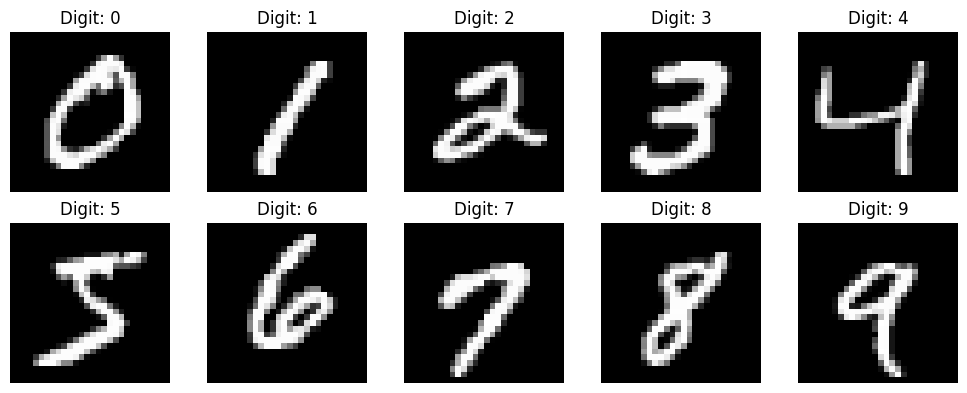

Move forward: Dimension matched.


In [20]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("mnist_dataset.csv")

assert len(X_train) == len(y_train), f"Error: X={len(X_train)}, y={len(y_train)}"

print("Move forward: Dimension matched.")

One Hot Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder

if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)

    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

9. Inatialization and Training the Model

In [22]:
d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

Iteration: 0 Cost: 2.207349196156921
Iteration: 100 Cost: 0.6076514512405864
Iteration: 200 Cost: 0.48974024939390004
Iteration: 300 Cost: 0.44102791363022575
Iteration: 400 Cost: 0.41288952248210975
Iteration: 500 Cost: 0.3939875691103115
Iteration: 600 Cost: 0.38014507677220155
Iteration: 700 Cost: 0.3694252237229958
Iteration: 800 Cost: 0.3607929693112032
Iteration: 900 Cost: 0.35363872498646043


COST VS ITERATION GRAPH

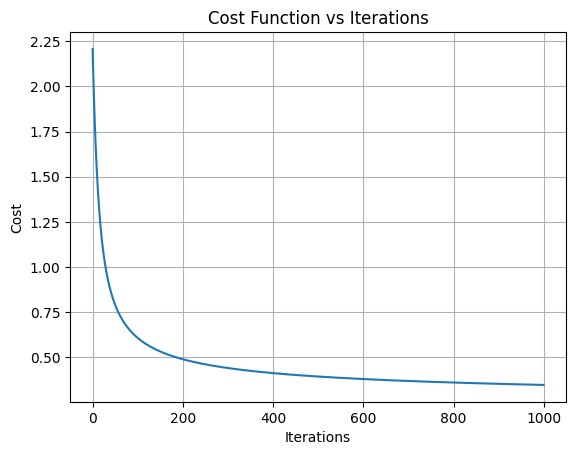

In [23]:
plt.plot(cost_history)
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

10. Evaluate Model

In [24]:
def evaluate_classification(y_true,y_pred):

    cm=confusion_matrix(y_true,y_pred)

    precision=precision_score(y_true,y_pred,average='weighted')
    recall=recall_score(y_true,y_pred,average='weighted')
    f1=f1_score(y_true,y_pred,average='weighted')

    return cm,precision,recall,f1

Predict & Evaluate

In [25]:
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Confusion Matrix:
[[1126    0    5    2    3   12    9    2   13    3]
 [   0 1274    7   11    1    5    1    4   18    1]
 [   1   15 1028   16   19    4   27   25   31    8]
 [   8    5   33 1051    1   52    9    8   31   21]
 [   1    5    7    1 1093    0   10    4    4   51]
 [  22   14   12   43   12  924   14    7   43   13]
 [   7    2    9    1   11   16 1119    2   10    0]
 [   7   27   25    5   16    2    0 1181    7   29]
 [   8   26   12   34    9   33   13    6 1004   15]
 [   8    6   10   18   43    9    0   38   10 1052]]
Precision: 0.90
Recall: 0.90
F1 Score: 0.90


Qsn 1:

Is extracting pixel values sufficient for effective feature extraction? Why or why not?

-> Extracting pixel values alone is not sufficient for effective feature extraction because it only represents raw intensity values of the image. It does not capture important features such as edges, shapes, and patterns. While it can still be used for simple models like softmax regression, it may not perform well for more complex tasks that require deeper feature understanding.

Qsn 2:

Provide an interpretation of the output based on your understanding.

-> The output indicates that logistic regression performs well on linearly separable data, as it can form a clear decision boundary between classes. However, for non-linearly separable data, the model performs poorly because it can only create a linear boundary, which is not suitable for more complex data distributions.

Qsn 3:

Describe any challenges you faced while implementing the code above.

-> Several challenges were encountered during implementation, including correctly implementing the softmax function and handling numerical stability. Managing matrix dimensions during calculations was also challenging. Additionally, debugging gradient computations and selecting appropriate values for parameters such as the learning rate required careful effort.